<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/3_Roots_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bisection Search

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
def bisection(f, a, b, tol=1e-4):
    """
    Find a root of f(x) in the interval [a,b] using the bisection method.

    Parameters:
        f   : function, the function for which we seek a root
        a   : float, left endpoint of the interval
        b   : float, right endpoint of the interval
        tol : float, stopping tolerance

    Returns:
        float: approximate root of f(x)
    """


    # check that f(a) and f(b) have opposite signs
    # (i.e., f(a)*f(b) < 0)
    # if not, raise an error because the IVT does not guarantee a root
    if (f(a)*f(b) > 0):
      raise ValueError("f(a) and f(b) must have opposite signs")


    fa = f(a)
    fb = f(b)

    # calculate the midpoint m = (a + b) / 2
    m = (a + b)/2
    fm = f(m)

    n = 1

    # start a while loop that runs while the interval length (b - a)
    # is greater than 2 * tol
    while (b - a) > 2*tol:

        # if f(m) is exactly 0,
        # then m is the root and we can stop
        if fm == 0:
            return m

        # elif f(a) and f(m) have opposite signs,
        # then the root lies in [a, m]
        # so set b = m

        elif f(a) * f(m) < 0:
            b = m
            fb = fm
        # elif f(m) and f(b) have opposite signs,
        # then the root lies in [m, b]
        # so set a = m

        else:  # f(m) * f(b) < 0
            a = m
            fa = fm

        n = n + 1
        m = (a + b) / 2
        fm = f(m)

    # when the interval is small enough,
    # return the midpoint m as the approximate root
    print(n)
    return m

In [ ]:
# 1) x^2 - 2 = 0 on [0, 2]
f1 = lambda x: 10*math.sin(x) - math.exp(x)
root1 = bisection(f1, 2, 5)
print("Test 1 root:", root1)
print("f(root1) =", f1(root1))


# 2) sin(x) + x^2 = 2 log(x) + 5 on [1, 5]
# Rearrange to f(x) = sin(x) + x^2 - 2log(x) - 5
f2 = lambda x: math.sin(x) + x**2 - 2*math.log(x) - 5
root2 = bisection(f2, 1, 5)
print("\nTest 2 root:", root2)
print("f(root2) =", f2(root2))

# 3) (5 - x)e^x = 5 on [0, 5]
# Rearrange to f(x) = (5 - x)e^x - 5
f3 = lambda x: (5 - x)*math.exp(x) - 5
root3 = bisection(f3, 0, 5)
print("\nTest 3 root:", root3)
print("f(root3) =", f3(root3))

15
Test 1 root: 2.134490966796875
f(root1) = 0.00012522551280547134
16

Test 2 root: 2.49530029296875
f(root2) = -6.394640067419743e-05
16

Test 3 root: 4.9651336669921875
f(root3) = -0.0026884323376341612


In [ ]:
# 4) 3 sin(x) + 9 = x^2 + cos(x) on [1, 5]
# Rearrange to g(x) = 3sin(x) + 9 - x^2 - cos(x)

g = lambda x: 10*math.sin(x) - math.exp(x)

root4 = bisection(g, 1, 5, tol=1e-4)

print("Test 4 root:", root4)
print("g(root4) =", g(root4))

16
Test 4 root: 2.13446044921875
g(root4) = 0.0005462342227069428


In [ ]:
import math

def bisection_for(f, a, b, tol=1e-5):

    fa = f(a)
    fb = f(b)

    if fa == 0:
        return a
    if fb == 0:
        return b
    if fa * fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    # Smallest n such that (b-a)/2^n <= tol
    n = math.ceil(math.log2((b - a) / tol))
    print(n)


    for i in range(n):
        m = (a + b) / 2
        fm = f(m)

        if fm == 0:
            return m

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return m

In [ ]:
g = lambda x: 3*math.sin(x) + 9 - x**2 - math.cos(x)

root4 = bisection_for(g, 1, 5, tol=1e-6)

print("Test 4 root:", root4)
print("g(root4) =", g(root4))

22
Test 4 root: 3.1556081771850586
g(root4) = -6.377990582562276e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def bisection_with_error_tracking(f, x_exact, a, b, tol):
    if f(a) * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs on [a,b].")

    errors = []

    while (b - a) / 2.0 > tol:
        m = (a + b) / 2.0
        fm = f(m)

        # record error at this midpoint
        errors.append(abs(m - x_exact))

        if fm == 0:
            break
        elif f(a) * fm < 0:
            b = m
        else:
            a = m

    return errors

# Exercise 3.15 equation:
# e^(x-3) + sqrt(x+6) = 4
# Rearrange to f(x) = e^(x-3) + sqrt(x+6) - 4
f = lambda x: math.exp(x - 3) + math.sqrt(x + 6) - 4

x_exact = 3
tol = 1e-7

errors = bisection_with_error_tracking(f, x_exact, 0, 5, tol)
errors

[0.5,
 0.75,
 0.125,
 0.1875,
 0.03125,
 0.046875,
 0.0078125,
 0.01171875,
 0.001953125,
 0.0029296875,
 0.00048828125,
 0.000732421875,
 0.0001220703125,
 0.00018310546875,
 3.0517578125e-05,
 4.57763671875e-05,
 7.62939453125e-06,
 1.1444091796875e-05,
 1.9073486328125e-06,
 2.86102294921875e-06,
 4.76837158203125e-07,
 7.152557373046875e-07,
 1.1920928955078125e-07,
 1.7881393432617188e-07,
 2.9802322387695312e-08]

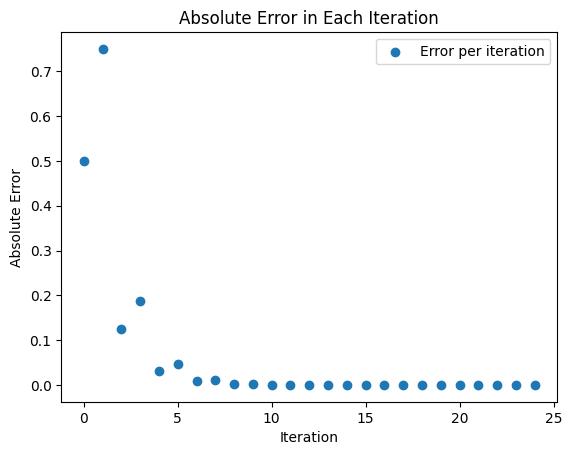

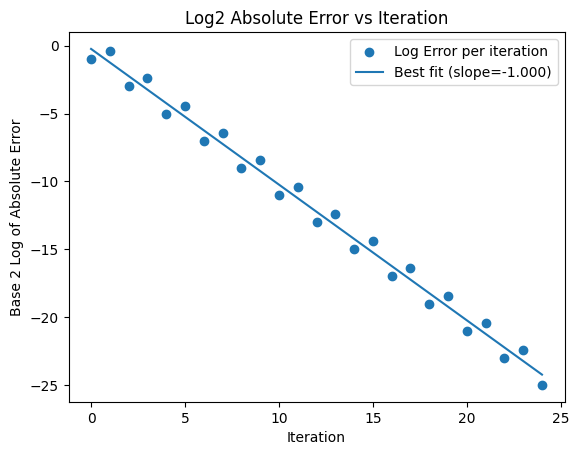

In [ ]:
def plot_errors(errors):
    iterations = np.arange(len(errors))
    plt.scatter(iterations, errors, label="Error per iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error in Each Iteration")
    plt.legend()
    plt.show()

def plot_log_errors(errors):
    iterations = np.arange(len(errors))
    log_errors = np.log2(np.array(errors))

    plt.scatter(iterations, log_errors, label="Log Error per iteration")

    slope, intercept = np.polyfit(iterations, log_errors, deg=1)
    best_fit_line = slope * iterations + intercept
    plt.plot(iterations, best_fit_line, label=f"Best fit (slope={slope:.3f})")

    plt.xlabel("Iteration")
    plt.ylabel("Base 2 Log of Absolute Error")
    plt.title("Log2 Absolute Error vs Iteration")
    plt.legend()
    plt.show()

plot_errors(errors)
plot_log_errors(errors)

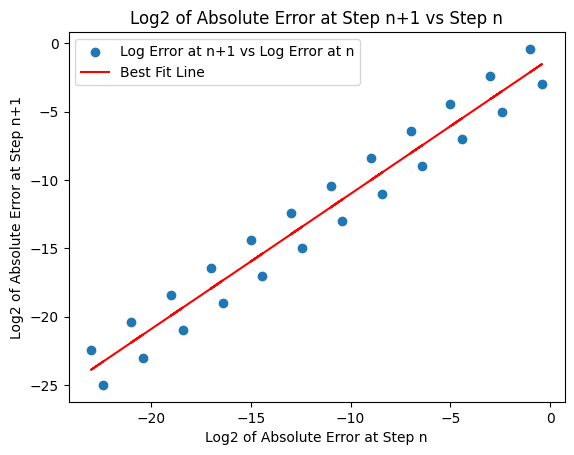

In [ ]:
def plot_error_progression(errors):
    # Calculating the log2 of the absolute error at step n and n+1
    log_errors = np.log2(errors)
    log_errors_n = log_errors[:-1]  # log errors at step n (excluding the last one)
    log_errors_n_plus_1 = log_errors[1:]  # log errors at step n+1 (excluding the first one)

    # Plotting log_errors_n+1 vs log_errors_n
    plt.scatter(log_errors_n, log_errors_n_plus_1, label='Log Error at n+1 vs Log Error at n')

    # Fitting a straight line to the data points
    slope, intercept = np.polyfit(log_errors_n, log_errors_n_plus_1, deg=1)
    best_fit_line = slope * log_errors_n + intercept
    plt.plot(log_errors_n, best_fit_line, color='red', label='Best Fit Line')

    # Setting up the plot
    plt.xlabel('Log2 of Absolute Error at Step n')
    plt.ylabel('Log2 of Absolute Error at Step n+1')
    plt.title('Log2 of Absolute Error at Step n+1 vs Step n')
    plt.legend()
    plt.show()

plot_error_progression(errors)

# Fixed Point Iteration

In [ ]:
x = 0.2
values = [x]

for i in range(10):
  x = math.cos(x)
  values.append(x)

for i in range(len(values)):
  print(f"x_{i} = {values[i]}")

x_0 = 0.2
x_1 = 0.9800665778412416
x_2 = 0.5569672528096424
x_3 = 0.8488621656582708
x_4 = 0.660837551116615
x_5 = 0.7894784377668683
x_6 = 0.7042157133419932
x_7 = 0.7621195617606609
x_8 = 0.7233741721055711
x_9 = 0.7495765763314931
x_10 = 0.7319774252581913


In [ ]:
def fixed_point(g, x0, tol=1e-8, n=1000):
    x = x0
    for i in range(n):
        y = x
        x = g(x)
        if abs(y - x) < tol:
            return x
    raise RuntimeError("Iteration has not converged")

# Use it for g(x) = cos(x), x0 = 2, tol = 1e-8
g = lambda x: math.cos(x)

p = fixed_point(g, x0=2, tol=1e-8, n=1000)
print("Fixed point approximation:", p)
print("Check cos(p) - p =", math.cos(p) - p)

Fixed point approximation: 0.7390851297739084
Check cos(p) - p = 5.759321131115769e-09
